# 03 — Heartbreak: The 2023 ODI World Cup

India went undefeated through the entire group stage, then lost the final to Australia on November 19, 2023. This notebook analyzes how Reddit reacted — before, during, and after the heartbreak.

### 1. Setup

In [1]:
import sys
sys.path.insert(0, "..")

from utils import (
    get_spark, load_cricket_submissions, load_cricket_comments,
    add_player_mentions, add_time_features, label_event_period,
    save_figure, save_pandas_to_local,
    EVENT_DATES,
)

from pyspark.sql import functions as F
from pyspark.sql.functions import col, count, avg, sum as ssum, when, lower, to_date
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120

### 2. Start Spark

In [2]:
spark = get_spark("03_Heartbreak2023WC")
spark

:: loading settings :: url = jar:file:/home/ubuntu/spark-3.5.1-bin-hadoop3/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/ubuntu/.ivy2/cache
The jars for the packages stored in: /home/ubuntu/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-bundle added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-960db9d3-dcf0-4cd8-934f-05db1bb954b9;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
:: resolution report :: resolve 433ms :: artifacts dl 22ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	org.apache.hadoop#hadoop-aws;3.3.4 from central in [default]
	org.wildfly.openssl#wildfly-openssl;1.0.7.Final from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evi

### 3. Load filtered data

In [3]:
subs = load_cricket_submissions(spark)
coms = load_cricket_comments(spark)
print("Loaded submissions and comments")

26/04/28 18:09:10 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties


Loaded submissions and comments


### 4. Add time features and event period labels

In [4]:
subs = add_time_features(subs, ts_col="created_utc")
subs = label_event_period(subs, ts_col="created_dt")

coms = add_time_features(coms, ts_col="created_utc")
coms = label_event_period(coms, ts_col="created_dt")

### 5. Narrow to WC 2023 window

In [5]:
wc_subs = subs.filter(
    (col("created_dt") >= EVENT_DATES["wc2023_start"]) &
    (col("created_dt") <= EVENT_DATES["wc2023_final_end"])
)
wc_coms = coms.filter(
    (col("created_dt") >= EVENT_DATES["wc2023_start"]) &
    (col("created_dt") <= EVENT_DATES["wc2023_final_end"])
)
print(f"WC 2023 submissions: {wc_subs.count():,}")
print(f"WC 2023 comments:    {wc_coms.count():,}")

WC 2023 submissions: 34,295


WC 2023 comments:    726,515


### 6. Daily post volume

In [6]:
daily_posts = (
    wc_subs
    .withColumn("date", to_date(col("created_dt")))
    .groupBy("date")
    .agg(count("*").alias("post_count"))
    .orderBy("date")
    .toPandas()
)
daily_posts["date"] = pd.to_datetime(daily_posts["date"])
print(daily_posts)

         date  post_count
0  2023-10-05         609
1  2023-10-06         510
2  2023-10-07         471
3  2023-10-08         791
4  2023-10-09         443
5  2023-10-10         530
6  2023-10-11         545
7  2023-10-12         485
8  2023-10-13         430
9  2023-10-14         872
10 2023-10-15         577
11 2023-10-16         391
12 2023-10-17         519
13 2023-10-18         446
14 2023-10-19         711
15 2023-10-20         600
16 2023-10-21         519
17 2023-10-22         667
18 2023-10-23         749
19 2023-10-24         504
20 2023-10-25         432
21 2023-10-26         518
22 2023-10-27         658
23 2023-10-28         601
24 2023-10-29         693
25 2023-10-30         518
26 2023-10-31         453
27 2023-11-01         510
28 2023-11-02         832
29 2023-11-03         551
30 2023-11-04         742
31 2023-11-05         942
32 2023-11-06         748
33 2023-11-07         944
34 2023-11-08         574
35 2023-11-09         627
36 2023-11-10         466
37 2023-11-1

### 7. Line chart — daily post volume

Saved to results/figures/03_daily_posts_wc2023.png


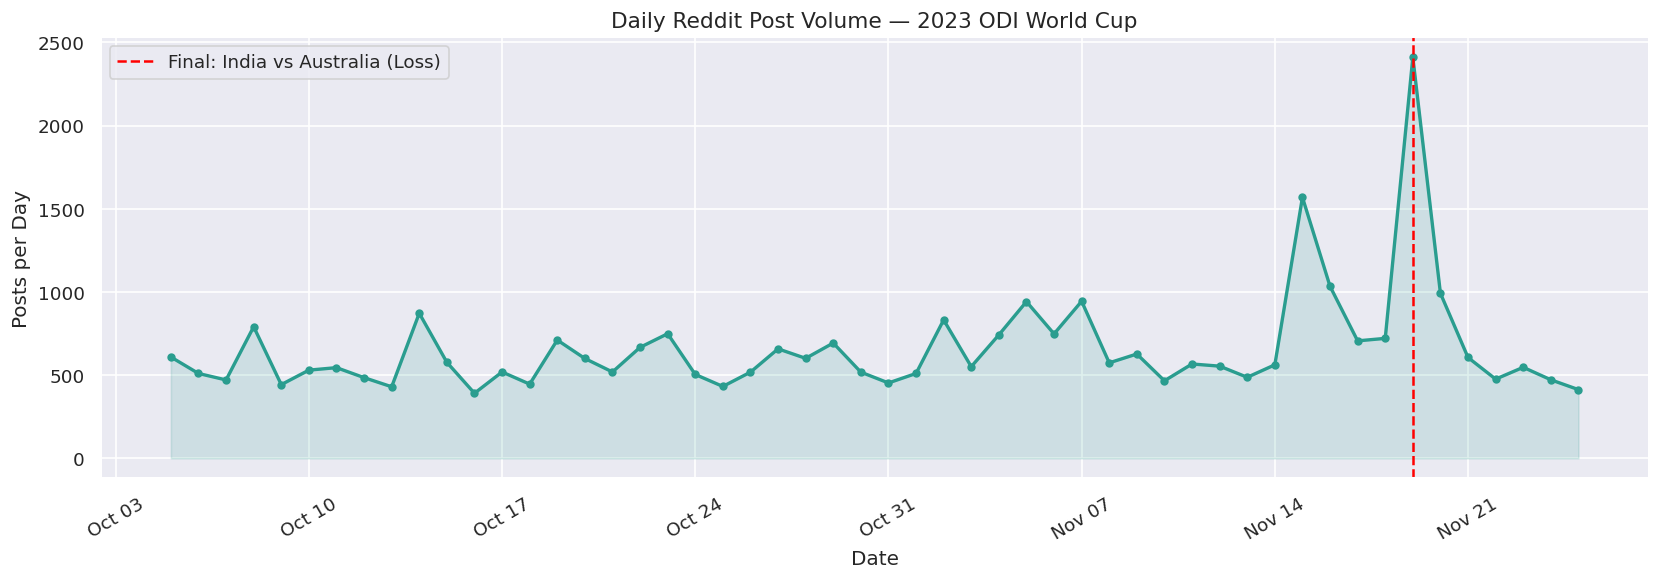

In [15]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_posts["date"], daily_posts["post_count"], color="#2a9d8f", linewidth=2, marker="o", markersize=4)
ax.axvline(EVENT_DATES["wc2023_final"], color="red", linestyle="--", linewidth=1.5, label="Final: India vs Australia (Loss)")
ax.fill_between(daily_posts["date"], daily_posts["post_count"], alpha=0.15, color="#2a9d8f")
ax.set_title("Daily Reddit Post Volume — 2023 ODI World Cup", fontsize=13)
ax.set_ylabel("Posts per Day")
ax.set_xlabel("Date")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=30)
plt.tight_layout()
save_figure(fig, "03_daily_posts_wc2023.png")
plt.show()

### 8. Player mentions during WC 2023

In [8]:
wc_subs = add_player_mentions(wc_subs, text_col="title")
wc_coms = add_player_mentions(wc_coms, text_col="body")

wc_mentions = wc_subs.agg(
    ssum(col("mentions_dhoni").cast("int")).alias("Dhoni"),
    ssum(col("mentions_kohli").cast("int")).alias("Kohli"),
    ssum(col("mentions_rohit").cast("int")).alias("Rohit"),
).toPandas()
print("Player mentions during WC 2023:")
print(wc_mentions)

Player mentions during WC 2023:
   Dhoni  Kohli  Rohit
0    425   1211   1190


### 9. Player mentions by event period

In [9]:
mentions_by_period = wc_subs.groupBy("event_period").agg(
    ssum(col("mentions_dhoni").cast("int")).alias("Dhoni"),
    ssum(col("mentions_kohli").cast("int")).alias("Kohli"),
    ssum(col("mentions_rohit").cast("int")).alias("Rohit"),
).toPandas()
print(mentions_by_period)
save_pandas_to_local(mentions_by_period, "03_wc2023_mentions_by_period.csv")

             event_period  Dhoni  Kohli  Rohit
0  wc2023_final_aftermath     87    153    219
1      wc2023_group_stage    338   1058    971
Saved to results/tables/03_wc2023_mentions_by_period.csv


### 10. Grouped bar — mentions by period

Saved to results/figures/03_wc2023_mentions_by_period.png


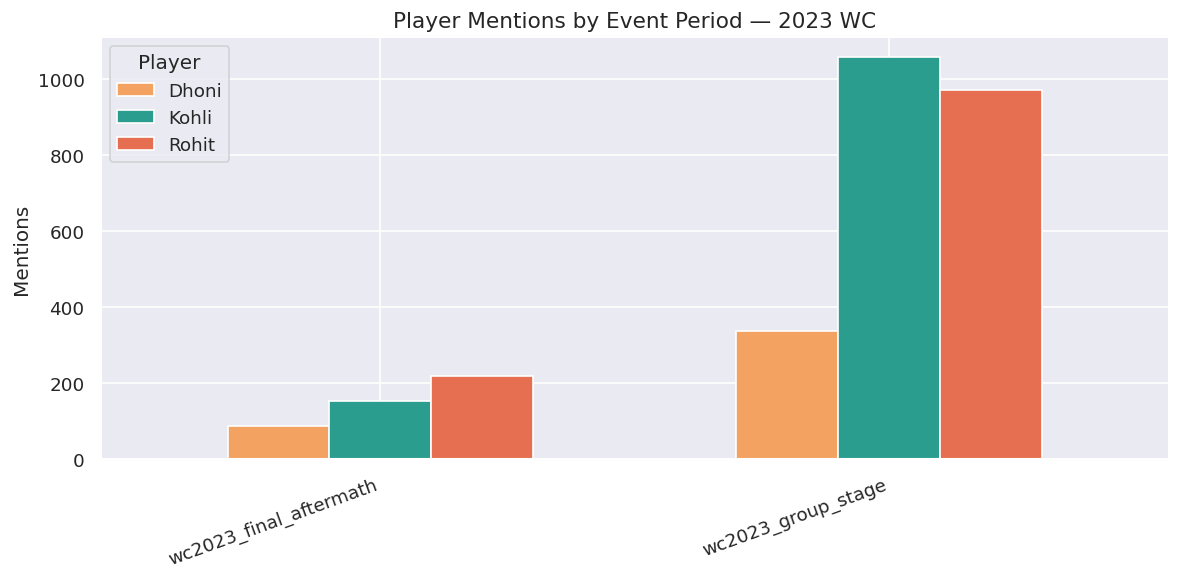

In [10]:
plot_df = mentions_by_period.set_index("event_period")[["Dhoni", "Kohli", "Rohit"]]
fig, ax = plt.subplots(figsize=(10, 5))
plot_df.plot(kind="bar", ax=ax, color=["#f4a261", "#2a9d8f", "#e76f51"], edgecolor="white", width=0.6)
ax.set_title("Player Mentions by Event Period — 2023 WC", fontsize=13)
ax.set_ylabel("Mentions")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="Player")
plt.tight_layout()
save_figure(fig, "03_wc2023_mentions_by_period.png")
plt.show()

### 11. Top posts after the final

In [11]:
top_aftermath = (
    wc_subs
    .filter(col("event_period") == "wc2023_final_aftermath")
    .select("title", "subreddit", "score", "num_comments", "created_dt")
    .orderBy(col("score").desc())
    .limit(10)
    .toPandas()
)
print(top_aftermath[["title", "subreddit", "score", "num_comments"]].to_string(index=False))
save_pandas_to_local(top_aftermath, "03_wc2023_top_aftermath_posts.csv")

                                                                                                                                                                      title       subreddit  score  num_comments
                                                                                                                                             Aussies are mentality monsters CricketShitpost  12418           761
                                                                                                                                                                   It hurts    IndiaCricket  10234           747
                                                                                                                          Australia are champions of the 2023 ODI World Cup         Cricket   9948          3278
                                                                                                                           No matter how old, this habit will never 

### 12. Engagement by period

In [12]:
engagement_by_period = (
    wc_subs
    .groupBy("event_period")
    .agg(
        count("*").alias("posts"),
        avg("score").alias("avg_score"),
        avg("num_comments").alias("avg_comments"),
    )
    .toPandas()
)
print(engagement_by_period)
save_pandas_to_local(engagement_by_period, "03_wc2023_engagement_by_period.csv")

             event_period  posts  avg_score  avg_comments
0  wc2023_final_aftermath   5917  71.188778     15.992395
1      wc2023_group_stage  28378  46.854606     39.431250
Saved to results/tables/03_wc2023_engagement_by_period.csv


### 13. Bar chart — engagement by period

/tmp/ipykernel_3714/3029178644.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(engagement_by_period["event_period"], rotation=20, ha="right")
/tmp/ipykernel_3714/3029178644.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(engagement_by_period["event_period"], rotation=20, ha="right")


Saved to results/figures/03_wc2023_engagement_by_period.png


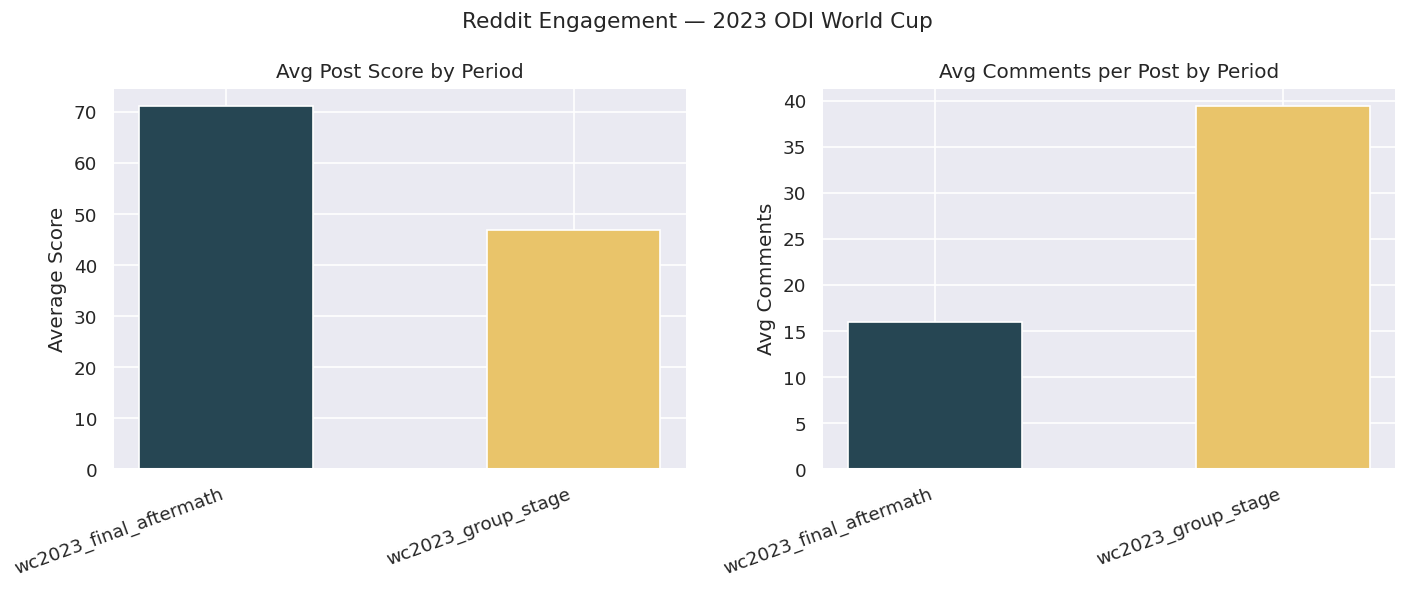

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors_period = ["#264653", "#e9c46a"]
n = len(engagement_by_period)

axes[0].bar(engagement_by_period["event_period"], engagement_by_period["avg_score"],
            color=colors_period[:n], edgecolor="white", width=0.5)
axes[0].set_title("Avg Post Score by Period")
axes[0].set_ylabel("Average Score")
axes[0].set_xticklabels(engagement_by_period["event_period"], rotation=20, ha="right")

axes[1].bar(engagement_by_period["event_period"], engagement_by_period["avg_comments"],
            color=colors_period[:n], edgecolor="white", width=0.5)
axes[1].set_title("Avg Comments per Post by Period")
axes[1].set_ylabel("Avg Comments")
axes[1].set_xticklabels(engagement_by_period["event_period"], rotation=20, ha="right")

plt.suptitle("Reddit Engagement — 2023 ODI World Cup", fontsize=13)
plt.tight_layout()
save_figure(fig, "03_wc2023_engagement_by_period.png")
plt.show()

### 14. Stop Spark

In [14]:
spark.stop()